# Lecture 23: The Marsden-Weinstein-Meyer Theorem

**Source span actually checked.** `pdftotext -f 149 -l 154` on `Lectures on Symplectic Geometry.pdf` returns Part IX, Lecture 23, printed pages 139-144, including the statement, the three ingredients, the slice-theorem sketch, the proof, and the commuting-Hamiltonian-action remark. The course inventory lists physical PDF pages 153-158; that page argument begins at the proof and spills into Lecture 24, so this notebook records the text-verified span.

**Goal.** Turn the theorem into a computational picture: a zero level of a moment map is cut out regularly, the group orbits are exactly the null directions of the restricted form, quotienting removes those null directions, and the surviving two-form is closed and nondegenerate.


In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not find Lectures-on-Symplectic-Geometry book root")


BOOK_ROOT = find_book_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-23"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def book_rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def write_json(path, payload):
    path = Path(path)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return path


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def display_artifact(path, width=780, height=520):
    from IPython.display import HTML, Image, Markdown, display

    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path), width=width))
    elif suffix == ".html":
        display(HTML(f'<iframe src="{path.as_uri()}" width="100%" height="{height}" style="border:1px solid #ddd"></iframe>'))
    elif suffix == ".json":
        display(Markdown("```json\n" + path.read_text(encoding="utf-8") + "\n```"))
    else:
        display(Markdown(f"`{path}`"))

print({"book_root": str(BOOK_ROOT), "artifact_root": book_rel(ARTIFACT_ROOT)})


{'book_root': 'D:\\Geometry\\Lectures-on-Symplectic-Geometry', 'artifact_root': 'artifacts/lecture-23'}


## Library Routing

NetworkX is used for the Marsden-Weinstein-Meyer proof route because the theorem is a dependency statement: free action, regular level, kernel distribution, quotient, and pullback identity must line up. Matplotlib handles the isotropic quotient and Hopf reduction figures because those are low-dimensional linear and circle-action models. Plotly supplies the local-form lab because varying the transverse block exposes the nondegeneracy condition. NumPy records the rank, kernel, determinant, and dimension-drop checks.

## Compact Visualization Storyboard

The lecture has a proof shape rather than a long catalog of examples, so the storyboard is deliberately compact.

| Storyboard item | Representation | What to inspect | Invariant/check |
|---|---|---|---|
| Theorem route | NetworkX dependency graph | Free action feeds regular level, slice quotient, isotropic quotient, and pullback identity | Every conclusion has a source ingredient |
| Low-brow local model | Plotly area-density lab for the coefficient `D` in the local expression for `omega` | The reduced form is the `d eta1 wedge d eta2` part after setting `mu=0` and forgetting `theta` | `D` stays nonzero in the symplectic case and degeneracy is visible when `D=0` |
| Linear quotient lemma | Matrix diagram for `I subset I^omega` and `I^omega/I` | Orbit directions are null after restriction, while transverse classes inherit a symplectic matrix | Reduced matrix has determinant 1 and rank 2 |
| Concrete model | Hopf-fibration picture for diagonal `S^1` reduction of `C^2` | `mu^{-1}(0)` is a sphere, `S^1` fibers collapse, the base is `CP^1` | Dimension drops `4 -> 3 -> 2`; `ker dmu = (T orbit)^omega` |


In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
import networkx as nx
import plotly.graph_objects as go

# Chapter-specific storyboard and source notes.
storyboard = {
    "chapter_goal": "Explain Marsden-Weinstein-Meyer reduction as regular level plus null-foliation quotient plus induced closed symplectic form.",
    "source_span_read": {
        "pdf": "Lectures on Symplectic Geometry.pdf",
        "printed_pages": "139-144",
        "pdftotext_pages_used": "149-154",
        "inventory_pdf_span": "153-158",
        "verification": "The extracted text begins with Part IX / Symplectic Reduction and Lecture 23 / The Marsden-Weinstein-Meyer Theorem, then reaches the commuting-action remark on printed page 144."
    },
    "concept_inventory": [
        "MWM hypotheses: hamiltonian compact G-space, zero level, free action",
        "regular value consequence from im dmu_p = annihilator of stabilizer",
        "orbit tangent as isotropic subspace inside the zero level",
        "linear lemma: an isotropic subspace I gives a symplectic quotient I^omega / I",
        "slice theorem gives local quotient charts and principal bundle projection",
        "reduced form is defined by i^* omega = pi^* omega_red and is closed",
        "commuting hamiltonian actions descend when the second moment map is G-invariant"
    ],
    "library_routing_table": [
        {"concept": "proof dependencies", "representation": "directed graph", "library": "networkx + matplotlib", "why": "the proof is a dependency chain", "fallback": "markdown table"},
        {"concept": "local low-brow form", "representation": "hoverable area-density surface", "library": "plotly", "why": "learners can inspect where D stays nonzero", "fallback": "matplotlib heatmap"},
        {"concept": "isotropic quotient lemma", "representation": "matrix and subspace diagram", "library": "numpy + matplotlib", "why": "the quotient is an exact linear-algebra calculation", "fallback": "plain matrix printout"},
        {"concept": "C^2 diagonal S^1 reduction", "representation": "Hopf fibers and reduced sphere", "library": "matplotlib 3D", "why": "S^3 to CP^1 is the smallest faithful geometric model", "fallback": "dimension table"}
    ],
    "visual_sequence": [
        {"artifact": "artifacts/lecture-23/figures/mwm-proof-route.png", "concept": "proof dependency route", "inspection_target": "which ingredient supplies each theorem conclusion", "validation": "graph has a path from hypotheses to reduced closed symplectic form"},
        {"artifact": "artifacts/lecture-23/figures/isotropic-quotient-form.png", "concept": "linear quotient lemma", "inspection_target": "how null orbit directions disappear from I^omega/I", "validation": "reduced 2-form matrix has rank 2 and determinant 1"},
        {"artifact": "artifacts/lecture-23/figures/hopf-level-quotient.png", "concept": "free S^1 reduction of C^2", "inspection_target": "level set, orbit fibers, and CP^1 base", "validation": "dimension drop 4-1-1=2 and ker dmu=(T orbit)^omega"},
        {"artifact": "artifacts/lecture-23/interactive/lowbrow-local-form-lab.html", "concept": "low-brow local form", "inspection_target": "where the coefficient D makes the reduced form nondegenerate", "validation": "positive case min(D)>0; degenerate comparison has a zero contour"}
    ],
    "computational_checks": [
        "rank dmu = dim G at the chosen C^2 zero-level point",
        "orbit vector lies in ker dmu and is isotropic",
        "row span of dmu agrees with contraction of the orbit vector into omega up to convention",
        "quotient basis on I^omega/I has nondegenerate skew matrix",
        "all generated artifacts exist and have nonzero size"
    ]
}
write_json(CHECK_DIR / "visual-storyboard.json", storyboard)
write_json(CHECK_DIR / "source-span.json", storyboard["source_span_read"])

# 1. Proof route graph.
G = nx.DiGraph()
nodes = [
    ("Hamiltonian G-space\ncompact G", 0),
    ("free action on\nmu^{-1}(0)", 0),
    ("dmu_p surjective\n0 regular", 1),
    ("mu^{-1}(0)\nsubmanifold", 2),
    ("slice theorem\nquotient manifold", 2),
    ("principal\nG-bundle pi", 3),
    ("T_p orbit\nis isotropic", 1),
    ("ker dmu_p =\n(T_p orbit)^omega", 1),
    ("linear lemma\nI^omega/I", 2),
    ("T_[p] M_red\n= ker dmu / T_p orbit", 3),
    ("define omega_red\nby pullback", 4),
    ("d omega_red = 0\nby injective pi^*", 5),
    ("commuting H-action\nand invariant phi descend", 5),
]
for label, layer in nodes:
    G.add_node(label, layer=layer)
edges = [
    ("free action on\nmu^{-1}(0)", "dmu_p surjective\n0 regular"),
    ("dmu_p surjective\n0 regular", "mu^{-1}(0)\nsubmanifold"),
    ("Hamiltonian G-space\ncompact G", "slice theorem\nquotient manifold"),
    ("free action on\nmu^{-1}(0)", "slice theorem\nquotient manifold"),
    ("slice theorem\nquotient manifold", "principal\nG-bundle pi"),
    ("Hamiltonian G-space\ncompact G", "T_p orbit\nis isotropic"),
    ("free action on\nmu^{-1}(0)", "T_p orbit\nis isotropic"),
    ("Hamiltonian G-space\ncompact G", "ker dmu_p =\n(T_p orbit)^omega"),
    ("ker dmu_p =\n(T_p orbit)^omega", "linear lemma\nI^omega/I"),
    ("T_p orbit\nis isotropic", "linear lemma\nI^omega/I"),
    ("mu^{-1}(0)\nsubmanifold", "T_[p] M_red\n= ker dmu / T_p orbit"),
    ("principal\nG-bundle pi", "T_[p] M_red\n= ker dmu / T_p orbit"),
    ("linear lemma\nI^omega/I", "define omega_red\nby pullback"),
    ("T_[p] M_red\n= ker dmu / T_p orbit", "define omega_red\nby pullback"),
    ("define omega_red\nby pullback", "d omega_red = 0\nby injective pi^*"),
    ("define omega_red\nby pullback", "commuting H-action\nand invariant phi descend"),
]
G.add_edges_from(edges)
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.6)
fig, ax = plt.subplots(figsize=(13.5, 7.4))
colors = ["#f4c95d" if "free" in n or "Hamiltonian" in n else "#6bb6a8" if "lemma" in n or "isotropic" in n or "ker" in n else "#7b9acc" if "quotient" in n or "bundle" in n else "#d77a61" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.7, edge_color="#495057", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=3300, edgecolors="#2f3437", linewidths=1.0)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.6, font_weight="bold")
ax.set_title("Lecture 23 proof route: regular level + slice quotient + isotropic quotient", pad=18, fontsize=14)
ax.axis("off")
proof_route_path = FIG_DIR / "mwm-proof-route.png"
fig.tight_layout()
fig.savefig(proof_route_path, dpi=180)
plt.close(fig)

# 2. Linear quotient lemma diagram.
W = np.array([[0, 1, 0, 0], [-1, 0, 0, 0], [0, 0, 0, 1], [0, 0, -1, 0]], dtype=float)
I = np.eye(4)[:, [0]]
I_omega_basis = np.eye(4)[:, [0, 2, 3]]
Q = np.eye(4)[:, [2, 3]]
reduced_matrix = Q.T @ W @ Q
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4))
axes[0].axis("off")
axes[0].set_title("Subspaces in local coordinates", fontsize=12)
axes[0].add_patch(Rectangle((0.08, 0.12), 0.84, 0.72, facecolor="#dbeafe", edgecolor="#1d4ed8", lw=2))
axes[0].text(0.5, 0.78, "I^omega = {dmu = 0}", ha="center", va="center", fontsize=12, weight="bold")
axes[0].add_patch(Rectangle((0.18, 0.24), 0.22, 0.48, facecolor="#fecaca", edgecolor="#b91c1c", lw=2))
axes[0].text(0.29, 0.48, "I\norbit\nnull", ha="center", va="center", fontsize=11, weight="bold")
axes[0].add_patch(Rectangle((0.48, 0.24), 0.34, 0.48, facecolor="#bbf7d0", edgecolor="#15803d", lw=2))
axes[0].text(0.65, 0.48, "classes\n[eta1],[eta2]", ha="center", va="center", fontsize=11, weight="bold")
axes[0].text(0.5, 0.08, "quotient removes I and keeps a transverse symplectic pair", ha="center", fontsize=9)
im1 = axes[1].imshow(W, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_title("ambient omega matrix")
axes[1].set_xticks(range(4), ["theta", "mu", "eta1", "eta2"], rotation=45, ha="right")
axes[1].set_yticks(range(4), ["theta", "mu", "eta1", "eta2"])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, int(W[i, j]), ha="center", va="center", fontsize=11)
im2 = axes[2].imshow(reduced_matrix, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_title("induced matrix on I^omega / I")
axes[2].set_xticks(range(2), ["[eta1]", "[eta2]"])
axes[2].set_yticks(range(2), ["[eta1]", "[eta2]"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, int(reduced_matrix[i, j]), ha="center", va="center", fontsize=13, weight="bold")
fig.suptitle("Lemma 23.3 as a visible quotient: a null orbit direction is divided out", fontsize=14)
fig.tight_layout()
isotropic_path = FIG_DIR / "isotropic-quotient-form.png"
fig.savefig(isotropic_path, dpi=180)
plt.close(fig)

# 3. Hopf model for diagonal S^1 reduction of C^2.
def spinor_from_s2(point):
    x, y, z = point
    if z < -0.999999:
        return 0.0 + 0.0j, 1.0 + 0.0j
    z1 = math.sqrt((1 + z) / 2)
    z2 = (x + 1j * y) / math.sqrt(2 * (1 + z))
    return z1, z2


def stereographic_s3_to_r3(z1, z2):
    coords = np.array([np.real(z1), np.imag(z1), np.real(z2), np.imag(z2)])
    denom = 1.0 - coords[3]
    return coords[:3] / denom

base_points = [
    np.array([0.0, 0.0, 1.0]),
    np.array([0.85, 0.0, 0.5267826876]),
    np.array([0.0, 0.85, -0.5267826876]),
    np.array([-0.72, 0.42, 0.554436651]),
]
theta = np.linspace(0, 2 * np.pi, 360)
fig = plt.figure(figsize=(13.5, 6.2))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
palette = ["#0f766e", "#b45309", "#2563eb", "#be123c"]
for point, color in zip(base_points, palette):
    z1, z2 = spinor_from_s2(point)
    curve = np.array([stereographic_s3_to_r3(np.exp(1j * t) * z1, np.exp(1j * t) * z2) for t in theta])
    good = np.all(np.isfinite(curve), axis=1) & (np.linalg.norm(curve, axis=1) < 12)
    ax1.plot(curve[good, 0], curve[good, 1], curve[good, 2], color=color, lw=2.0)
ax1.set_title("four S^1 orbits in mu^{-1}(0) = S^3\n(stereographic projection)")
ax1.set_xlabel("x1")
ax1.set_ylabel("y1")
ax1.set_zlabel("x2")
ax1.view_init(22, -58)
limit = 3.5
ax1.set_xlim(-limit, limit)
ax1.set_ylim(-limit, limit)
ax1.set_zlim(-limit, limit)

u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones_like(u), np.cos(v))
ax2.plot_surface(X, Y, Z, alpha=0.14, color="#94a3b8", linewidth=0)
for point, color in zip(base_points, palette):
    ax2.scatter([point[0]], [point[1]], [point[2]], s=70, color=color, depthshade=True)
ax2.set_title("each orbit collapses to one point of CP^1 ~= S^2")
ax2.set_xlabel("2 Re(z1 conj z2)")
ax2.set_ylabel("2 Im(z1 conj z2)")
ax2.set_zlabel("|z1|^2 - |z2|^2")
ax2.set_box_aspect((1, 1, 1))
ax2.view_init(24, 42)
fig.suptitle("Concrete MWM model: diagonal S^1 reduction of C^2 at a regular level", fontsize=14)
fig.tight_layout()
hopf_path = FIG_DIR / "hopf-level-quotient.png"
fig.savefig(hopf_path, dpi=180)
plt.close(fig)

# 4. Plotly low-brow local-form lab.
grid = np.linspace(-2.4, 2.4, 80)
eta1, eta2 = np.meshgrid(grid, grid)
D_positive = 1.15 + 0.22 * np.cos(eta1) + 0.16 * np.sin(eta2)
D_degenerate = eta1**2 - eta2**2
fig_plotly = go.Figure()
fig_plotly.add_trace(go.Surface(x=eta1, y=eta2, z=D_positive, colorscale="Viridis", name="symplectic D", showscale=True, visible=True))
fig_plotly.add_trace(go.Surface(x=eta1, y=eta2, z=D_degenerate, colorscale="RdBu", name="degenerate comparison", showscale=False, visible=False))
fig_plotly.update_layout(
    title="Low-brow local form: i^* omega = D(eta1, eta2) d eta1 wedge d eta2",
    scene=dict(xaxis_title="eta1", yaxis_title="eta2", zaxis_title="D coefficient"),
    updatemenus=[{
        "buttons": [
            {"label": "symplectic: D stays nonzero", "method": "update", "args": [{"visible": [True, False]}, {"title": "Low-brow local form: nonzero D gives omega_red"}]},
            {"label": "failed hypothesis: D crosses zero", "method": "update", "args": [{"visible": [False, True]}, {"title": "Degenerate comparison: zero D kills nondegeneracy"}]},
        ],
        "direction": "down",
        "x": 0.02,
        "y": 0.98,
    }],
    margin=dict(l=0, r=0, t=60, b=0),
)
html_path = HTML_DIR / "lowbrow-local-form-lab.html"
fig_plotly.write_html(str(html_path), include_plotlyjs="cdn", full_html=True)

# Linear and model checks used by the notebook and final sanity cell.
r = math.sqrt(2.0)
x = np.array([r, 0.0, 0.0, 0.0])
W_c2 = W.copy()
dmu = np.array([r, 0.0, 0.0, 0.0])
# This sign convention uses the infinitesimal generator for e^{-it} . z, so i_X omega = dmu.
Xsharp = np.array([0.0, -r, 0.0, 0.0])
contraction = Xsharp @ W_c2
ker_basis = np.eye(4)[:, [1, 2, 3]]
horizontal_basis = np.eye(4)[:, [2, 3]]
quotient_form = horizontal_basis.T @ W_c2 @ horizontal_basis
linear_checks = {
    "ambient_coordinates": ["x1", "y1", "x2", "y2"],
    "moment_model": "mu(z1,z2)=0.5*(|z1|^2+|z2|^2)-1 for the diagonal S^1 action on C^2",
    "point_on_zero_level": x.tolist(),
    "dmu_rank": int(np.linalg.matrix_rank(dmu.reshape(1, -1))),
    "dmu_surjective_for_s1": bool(np.linalg.matrix_rank(dmu.reshape(1, -1)) == 1),
    "orbit_vector": Xsharp.tolist(),
    "orbit_in_kernel_dmu_residual": float(abs(dmu @ Xsharp)),
    "moment_contraction_residual": float(np.linalg.norm(contraction - dmu)),
    "orbit_isotropic_value": float(Xsharp @ W_c2 @ Xsharp),
    "kernel_basis_dimension": int(ker_basis.shape[1]),
    "quotient_dimension": int(horizontal_basis.shape[1]),
    "ambient_dimension": 4,
    "level_dimension": 3,
    "reduced_dimension": 2,
    "dimension_formula_value": 4 - 2 * 1,
    "reduced_form_matrix": quotient_form.tolist(),
    "reduced_form_rank": int(np.linalg.matrix_rank(quotient_form)),
    "reduced_form_determinant": float(np.linalg.det(quotient_form)),
    "lowbrow_D_positive_min": float(D_positive.min()),
    "lowbrow_D_degenerate_min_abs": float(np.min(np.abs(D_degenerate))),
}
write_json(CHECK_DIR / "linear-reduction-checks.json", linear_checks)

artifact_paths = [proof_route_path, isotropic_path, hopf_path, html_path, CHECK_DIR / "visual-storyboard.json", CHECK_DIR / "source-span.json", CHECK_DIR / "linear-reduction-checks.json"]
print(json.dumps({"generated": [book_rel(p) for p in artifact_paths]}, indent=2))


{
  "generated": [
    "artifacts/lecture-23/figures/mwm-proof-route.png",
    "artifacts/lecture-23/figures/isotropic-quotient-form.png",
    "artifacts/lecture-23/figures/hopf-level-quotient.png",
    "artifacts/lecture-23/interactive/lowbrow-local-form-lab.html",
    "artifacts/lecture-23/checks/visual-storyboard.json",
    "artifacts/lecture-23/checks/source-span.json",
    "artifacts/lecture-23/checks/linear-reduction-checks.json"
  ]
}


## The theorem as computational objects

The theorem starts with a Hamiltonian `G`-space `(M, omega, G, mu)` and asks what remains after two operations: first cut the phase space by the equation `mu=0`, then identify points that differ by the `G`-action. The free-action hypothesis is doing two jobs at once.

First, it makes `0` a regular value because the image of `dmu_p` is the annihilator of the stabilizer algebra. With no stabilizer algebra, `dmu_p` reaches all of `g^*`. Second, after the slice theorem supplies local quotient charts, freeness makes the projection `pi: mu^{-1}(0) -> mu^{-1}(0)/G` a principal `G`-bundle rather than an orbifold-like quotient.

The graph below is the proof map I will use for the rest of the notebook. The green branch is the linear-algebra branch; the blue branch is the quotient-manifold branch; the red nodes are the final form and the descending-action remark.


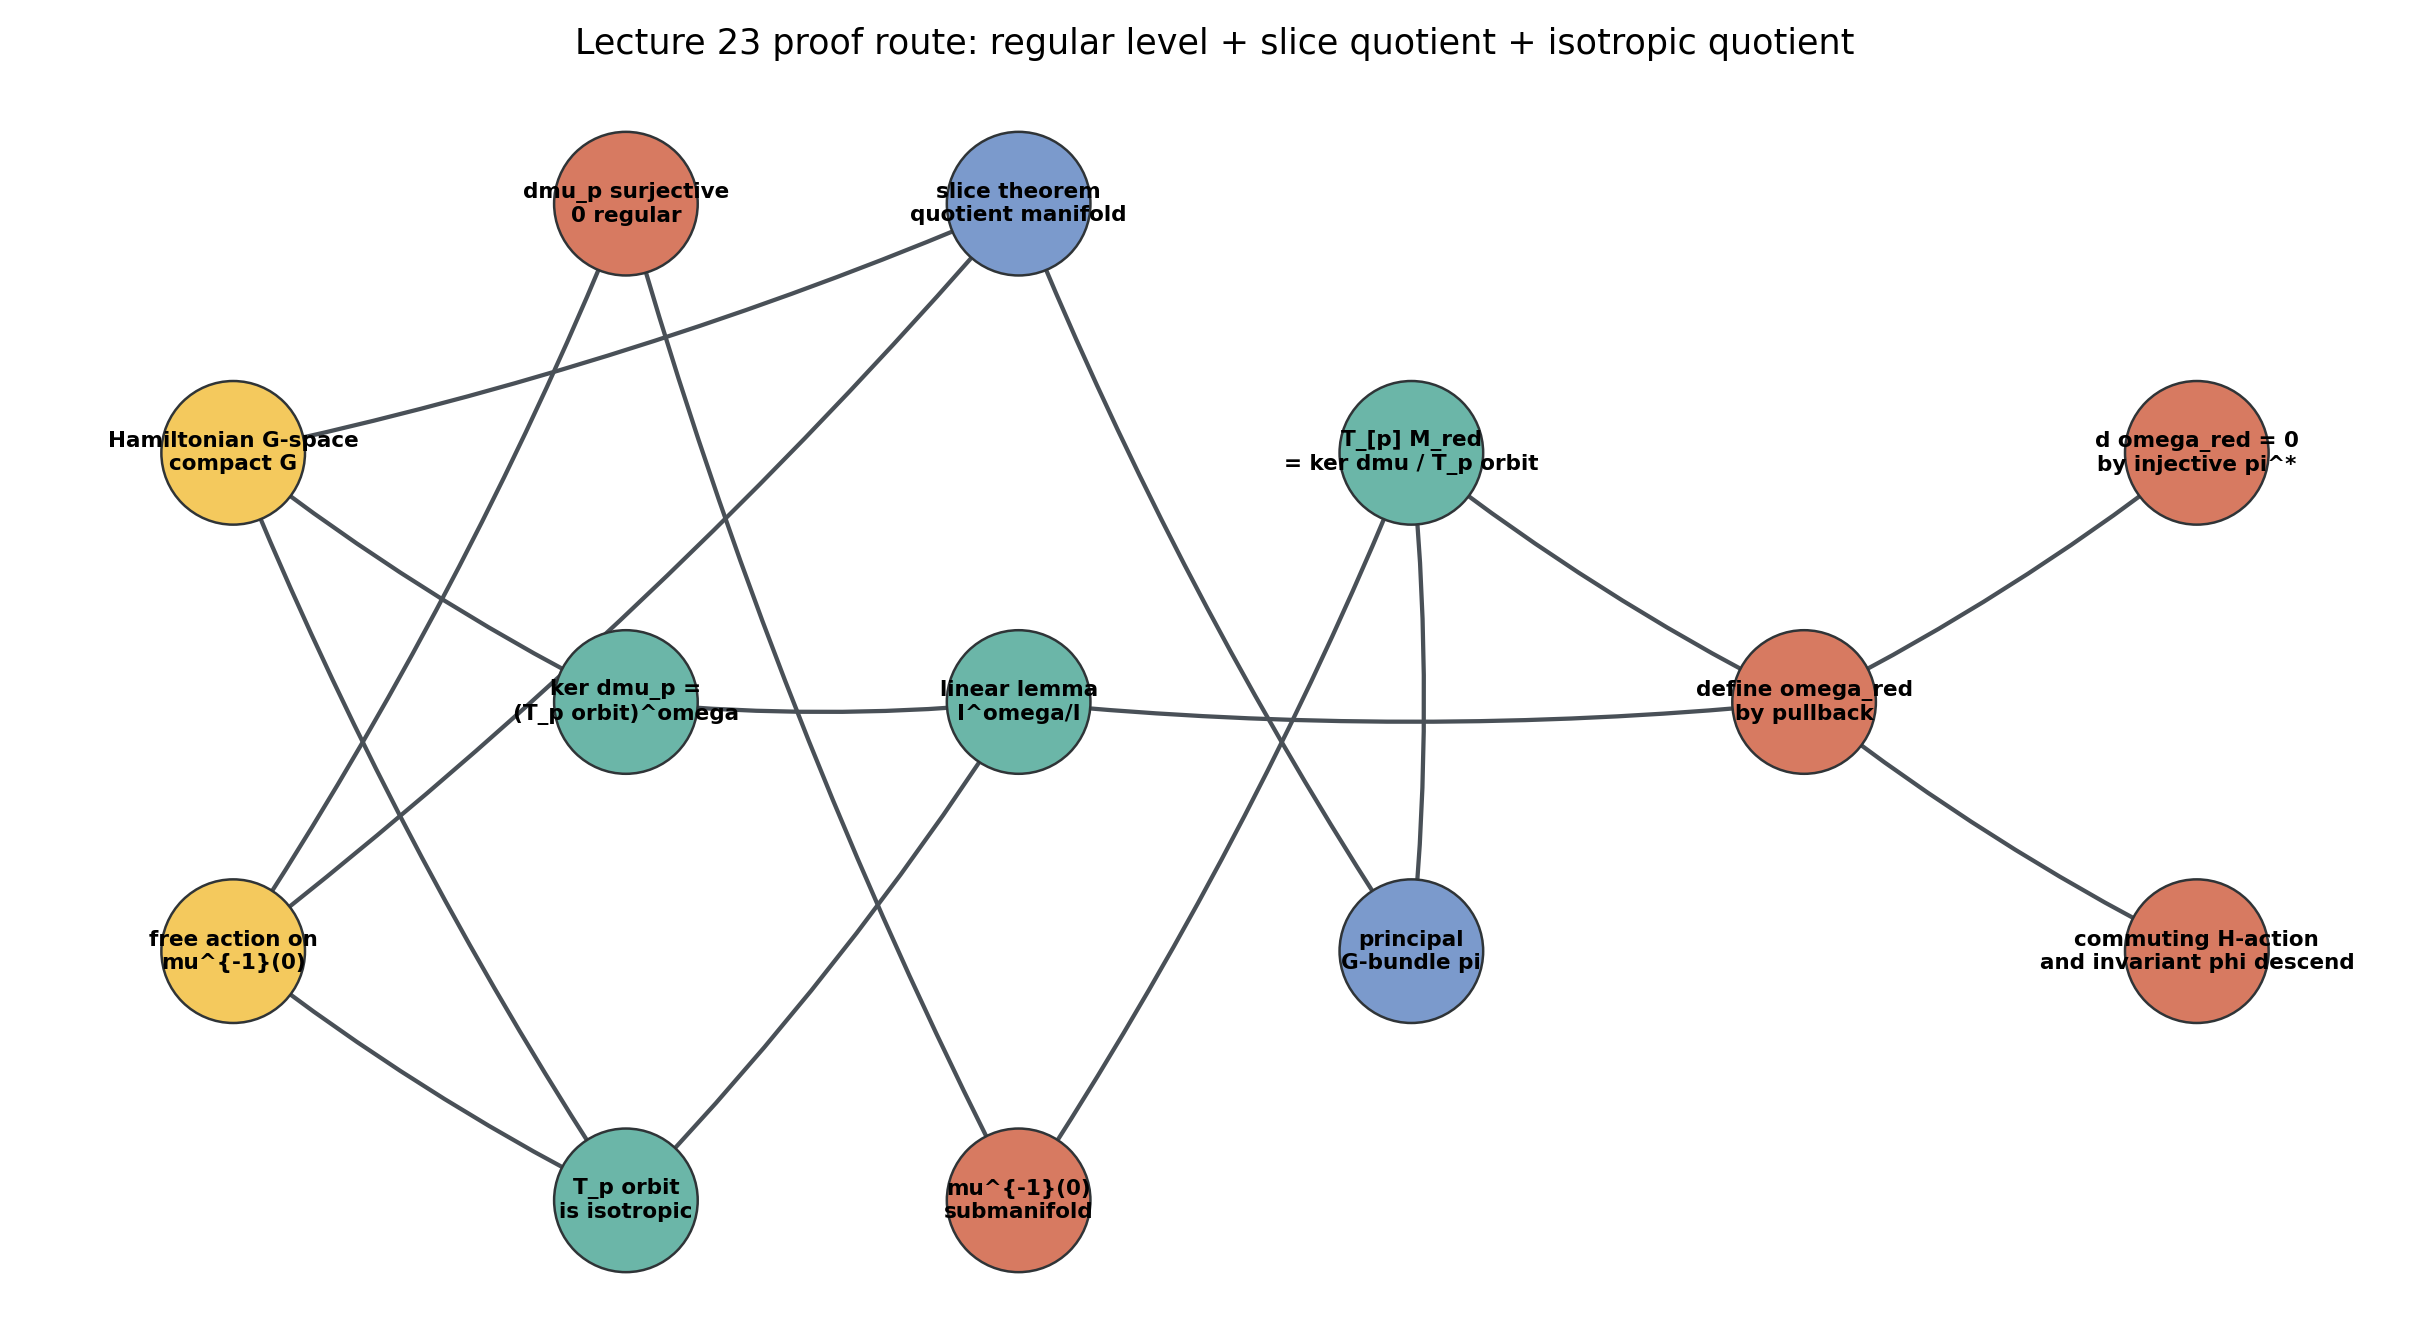

In [3]:
display_artifact(FIG_DIR / "mwm-proof-route.png", width=900)


## Ingredient 1: the moment map detects orbit directions

For a Hamiltonian action the infinitesimal generator `X#` and the component of the moment map in the `X` direction satisfy a contraction identity. Depending on sign convention, this is written as either `d mu^X = i_{X#} omega` or with a minus sign. The source uses the contraction identity to conclude

`ker dmu_p = (T_p O_p)^omega` and `im dmu_p = g_p^0`.

Here is the concrete regular model behind the theorem. Let `S^1` act diagonally on `C^2` and take

`mu(z1,z2) = 1/2 (|z1|^2 + |z2|^2) - 1`.

The zero level is `S^3`, the action is free, and the quotient is `CP^1`. At the point `(sqrt(2),0,0,0)`, the kernel of `dmu` is the tangent space of the sphere, the orbit direction is a null direction of the restricted form, and the quotient leaves a two-dimensional symplectic vector space.


In [4]:
checks = read_json(CHECK_DIR / "linear-reduction-checks.json")
summary = {
    "dmu_rank": checks["dmu_rank"],
    "orbit_in_kernel_residual": checks["orbit_in_kernel_dmu_residual"],
    "contraction_residual": checks["moment_contraction_residual"],
    "orbit_isotropic_value": checks["orbit_isotropic_value"],
    "dimension_formula_value": checks["dimension_formula_value"],
}
print(json.dumps(summary, indent=2))
assert checks["dmu_surjective_for_s1"]
assert checks["orbit_in_kernel_dmu_residual"] < 1e-12
assert checks["moment_contraction_residual"] < 1e-12
assert abs(checks["orbit_isotropic_value"]) < 1e-12
assert checks["dimension_formula_value"] == checks["reduced_dimension"]


{
  "dmu_rank": 1,
  "orbit_in_kernel_residual": 0.0,
  "contraction_residual": 0.0,
  "orbit_isotropic_value": 0.0,
  "dimension_formula_value": 2
}


## Ingredient 2: the isotropic quotient is the reduced tangent space

The linear lemma says: if `I` is isotropic inside a symplectic vector space, then the form descends to `I^omega / I`. This is the exact tangent-space model for the reduced space:

`T_[p] M_red ~= T_p mu^{-1}(0) / T_p O_p = ker dmu_p / T_p O_p`.

The figure uses local coordinates `(theta, mu, eta1, eta2)`. The orbit direction is `partial_theta`. Its symplectic orthogonal is the level tangent space `dmu=0`, and the quotient keeps the two transverse classes represented by `eta1, eta2`.


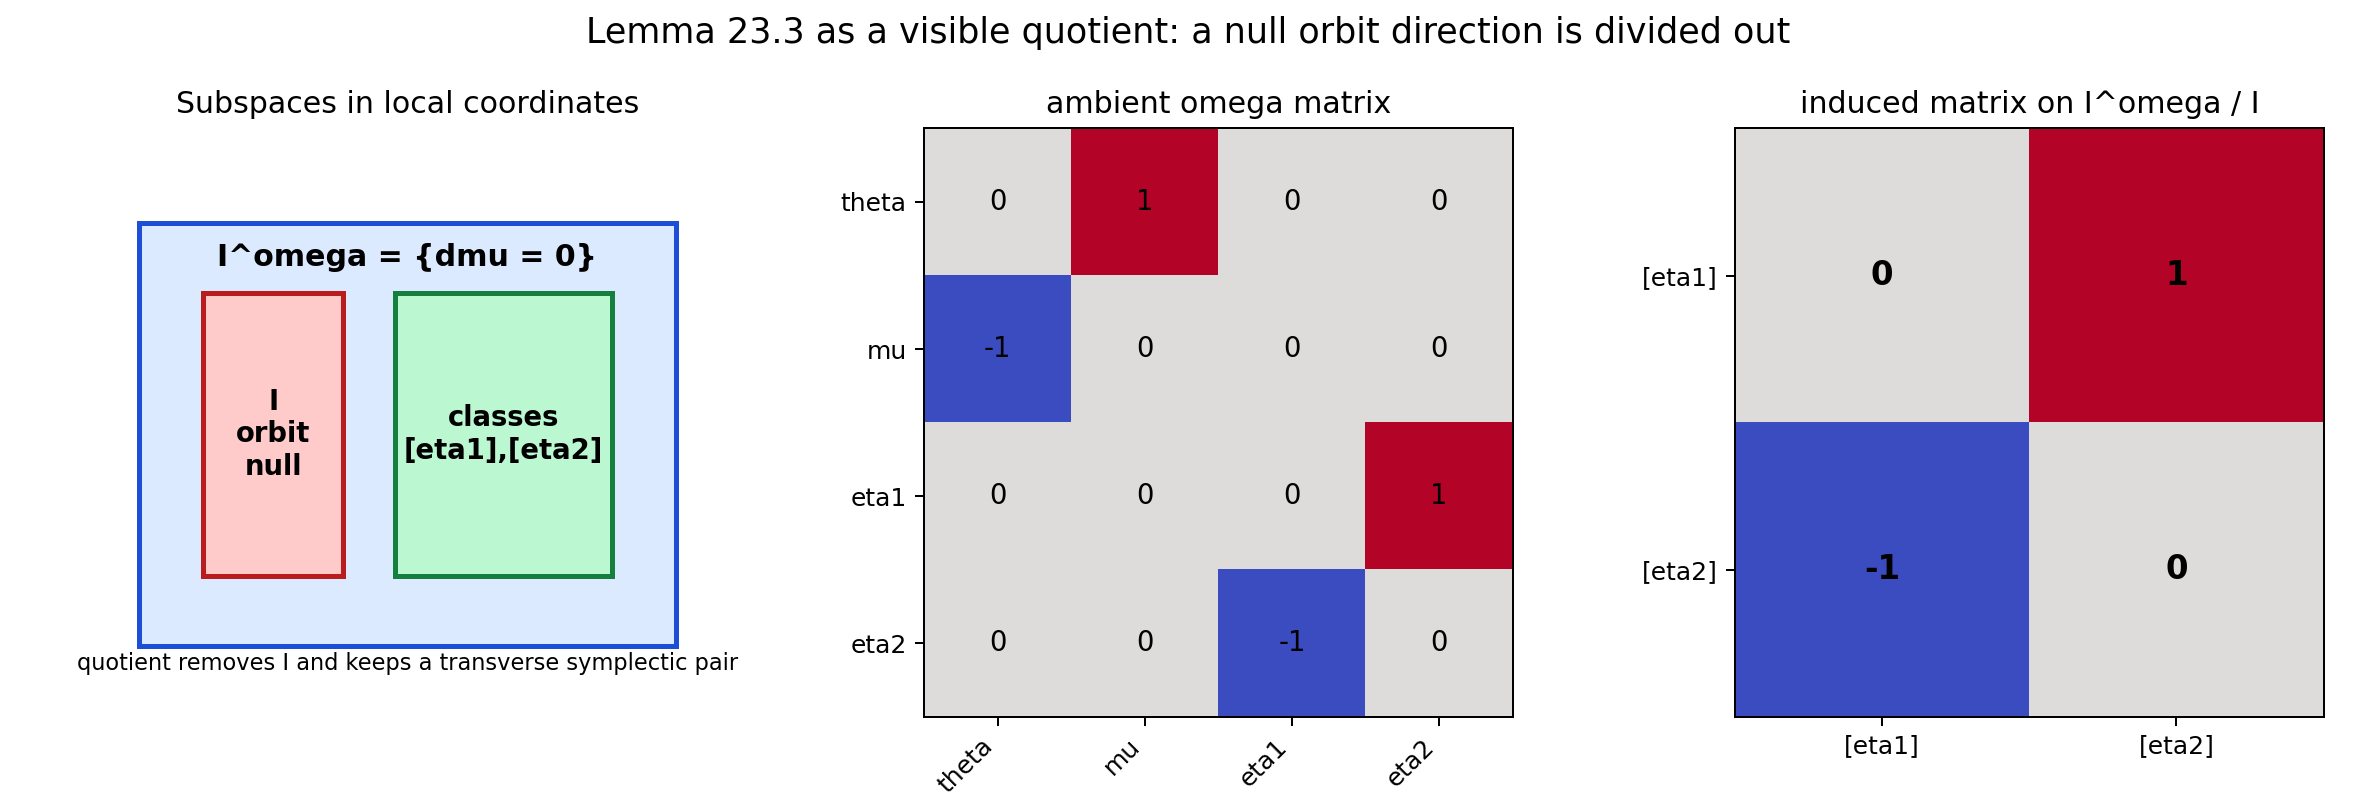

{'reduced_form_matrix': [[0.0, 1.0], [-1.0, 0.0]], 'rank': 2, 'determinant': 1.0}


In [5]:
display_artifact(FIG_DIR / "isotropic-quotient-form.png", width=900)
reduced = np.array(checks["reduced_form_matrix"], dtype=float)
print({"reduced_form_matrix": reduced.tolist(), "rank": int(np.linalg.matrix_rank(reduced)), "determinant": float(np.linalg.det(reduced))})
assert np.linalg.matrix_rank(reduced) == 2
assert abs(np.linalg.det(reduced) - 1.0) < 1e-12


## The low-brow local proof and the Hopf model

The source gives a local four-dimensional proof for `G=S^1`. Coordinates are chosen so `theta` follows the orbit, `mu` is the moment coordinate, and `eta1, eta2` come from the quotient. In those coordinates, the contraction identity forces the `d theta wedge dmu` coefficient to be nonzero and kills the `d theta wedge d eta_j` terms. On the level `mu=0`, the pullback keeps only

`i^* omega = D(eta1,eta2) d eta1 wedge d eta2`.

So the reduced form is visible as the area density `D` on the `eta`-plane. The HTML lab includes a comparison where `D` crosses zero; that is what would break nondegeneracy.

The second figure is a global model for the same theorem: diagonal `S^1` reduction of `C^2`. The level is `S^3`; each displayed orbit collapses to one point on the reduced `CP^1 ~= S^2`.


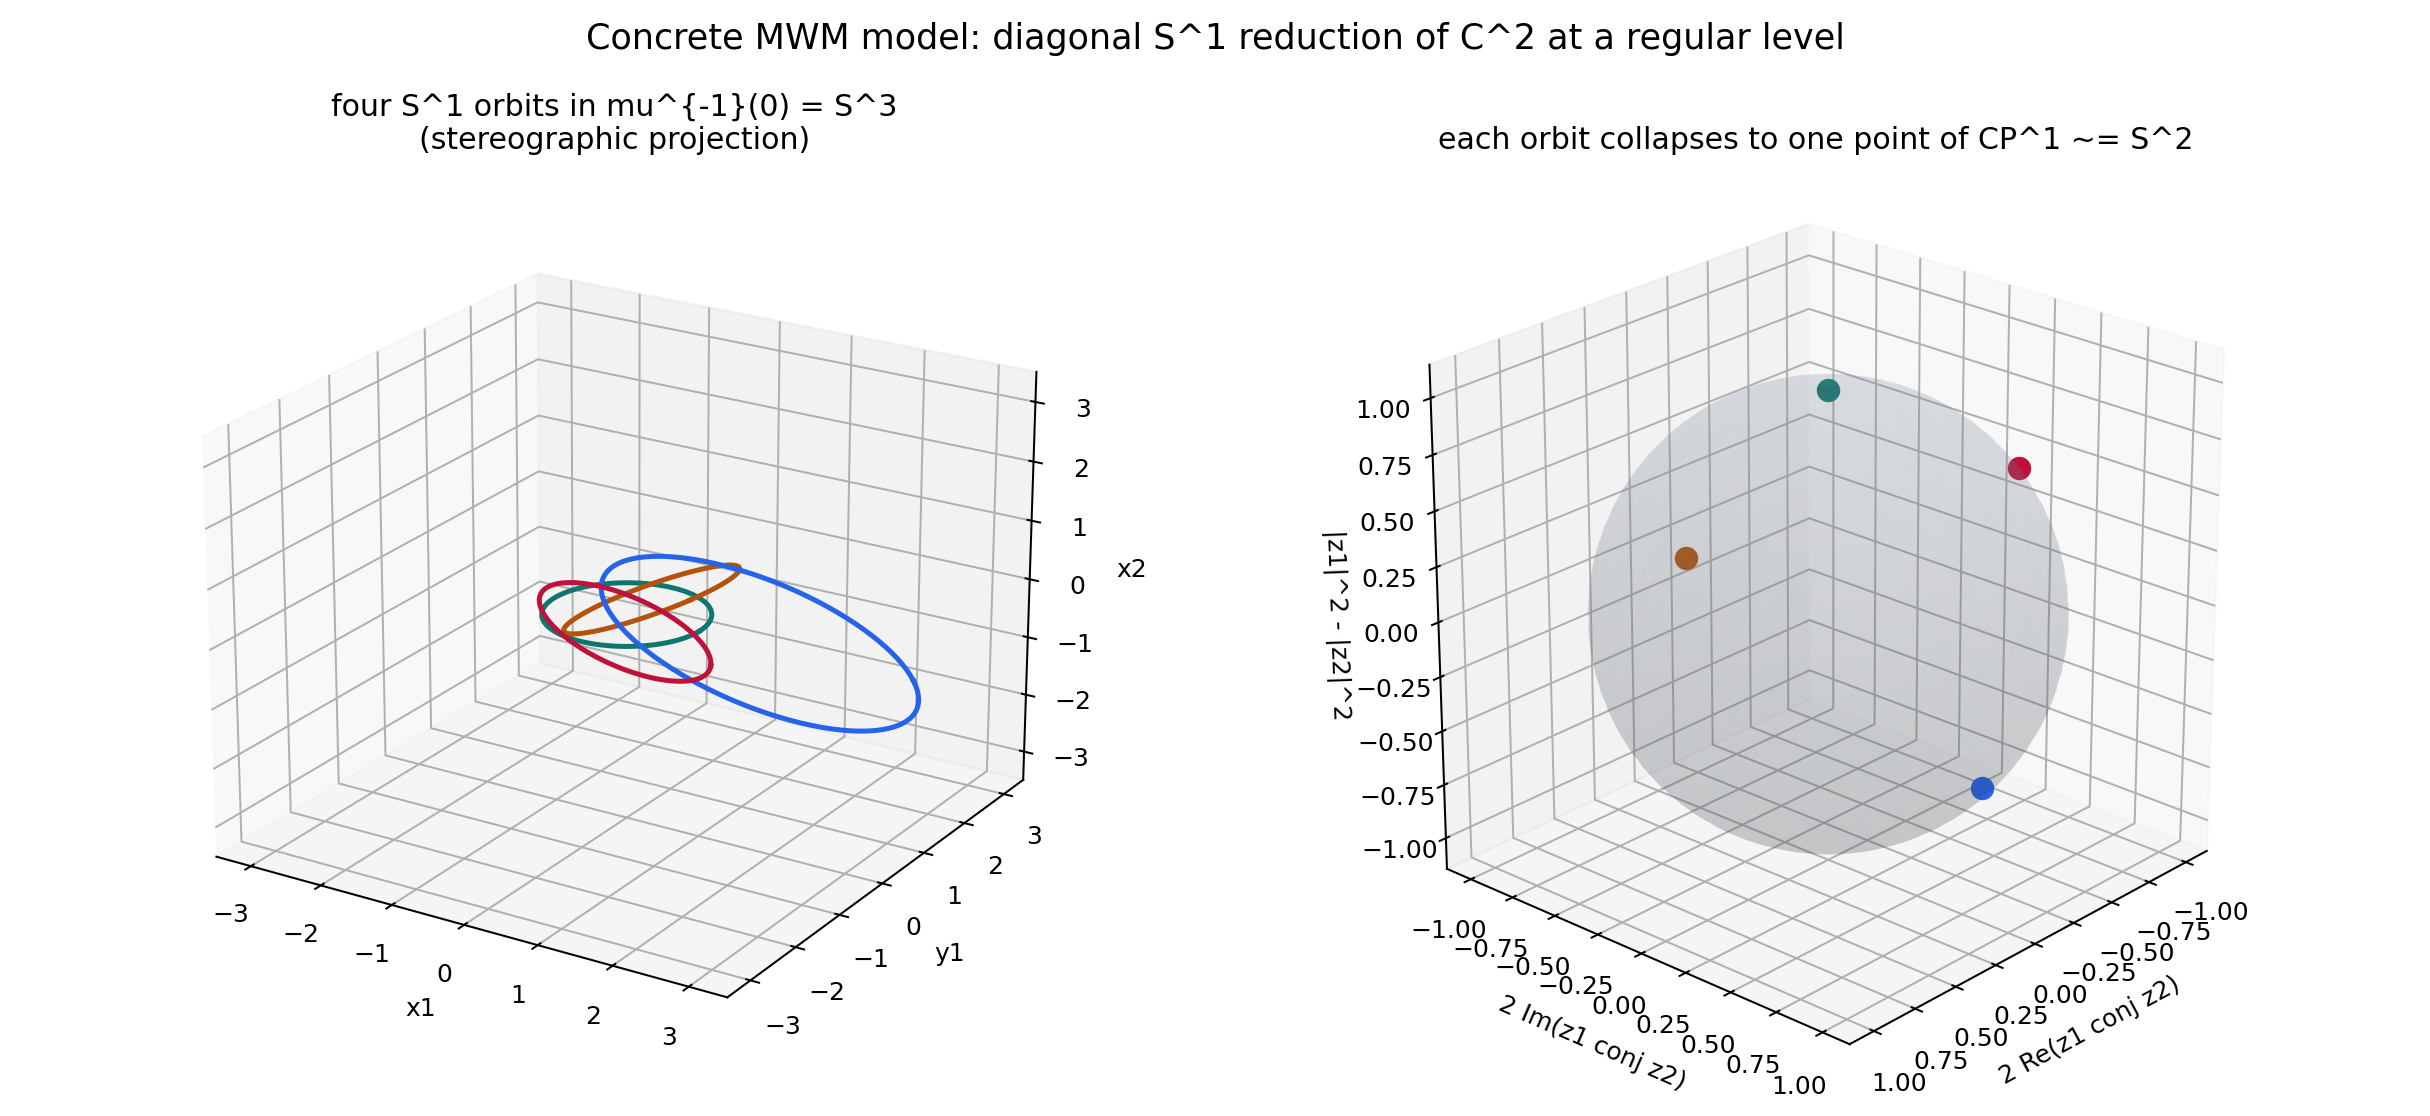

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'positive_D_min': 0.8278101181550512, 'degenerate_comparison_min_abs_D': 0.0}


In [6]:
display_artifact(FIG_DIR / "hopf-level-quotient.png", width=900)
display_artifact(HTML_DIR / "lowbrow-local-form-lab.html", height=560)
print({
    "positive_D_min": checks["lowbrow_D_positive_min"],
    "degenerate_comparison_min_abs_D": checks["lowbrow_D_degenerate_min_abs"],
})
assert checks["lowbrow_D_positive_min"] > 0


## Ingredient 3 and the final pullback identity

The slice theorem is the manifold part of the proof. Near a free orbit, a small transverse disk `S` gives a local model `G x S`. Dividing by `G` leaves the slice, so these slices become charts on the orbit space. Applied to the free action on `mu^{-1}(0)`, this proves that the reduced space is a manifold and that the projection is locally a product with fiber `G`.

The two-form is then defined by the identity

`i^* omega = pi^* omega_red`.

The linear quotient lemma gives nondegeneracy on each tangent quotient. Closedness comes from the pullback calculation: `pi^*(d omega_red) = d(pi^* omega_red) = d(i^* omega) = i^*(d omega) = 0`, and the submersion pullback `pi^*` is injective on forms.

The final remark in the lecture is also a quotient statement. If another Hamiltonian group action commutes with `G` and its moment map is `G`-invariant, then the action and moment map are constant along the `G`-fibers and therefore descend to `M_red`.


In [7]:
expected_artifacts = [
    FIG_DIR / "mwm-proof-route.png",
    FIG_DIR / "isotropic-quotient-form.png",
    FIG_DIR / "hopf-level-quotient.png",
    HTML_DIR / "lowbrow-local-form-lab.html",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "source-span.json",
    CHECK_DIR / "linear-reduction-checks.json",
]
artifact_sizes = {book_rel(path): path.stat().st_size for path in expected_artifacts}
assert all(size > 0 for size in artifact_sizes.values())
assert checks["reduced_form_rank"] == 2
assert abs(checks["reduced_form_determinant"] - 1.0) < 1e-12
assert checks["level_dimension"] == checks["ambient_dimension"] - 1
assert checks["reduced_dimension"] == checks["ambient_dimension"] - 2
assert checks["lowbrow_D_positive_min"] > 0

final_sanity = {
    "lecture": "Lecture 23: The Marsden-Weinstein-Meyer Theorem",
    "source_span_read": read_json(CHECK_DIR / "source-span.json"),
    "artifacts": artifact_sizes,
    "linear_checks": checks,
    "passed": True,
    "notes": [
        "The corrected pdftotext page arguments were used because the inventory PDF span begins too late for the lecture statement.",
        "The notebook verifies the local linear quotient and the C^2 diagonal S^1 reduction model.",
        "The final pullback closedness argument is represented textually because it is a naturality proof rather than a numerical identity."
    ]
}
write_json(CHECK_DIR / "final-sanity.json", final_sanity)
display_artifact(CHECK_DIR / "final-sanity.json", width=900)


```json
{
  "artifacts": {
    "artifacts/lecture-23/checks/linear-reduction-checks.json": 937,
    "artifacts/lecture-23/checks/source-span.json": 357,
    "artifacts/lecture-23/checks/visual-storyboard.json": 3756,
    "artifacts/lecture-23/figures/hopf-level-quotient.png": 497774,
    "artifacts/lecture-23/figures/isotropic-quotient-form.png": 86313,
    "artifacts/lecture-23/figures/mwm-proof-route.png": 299914,
    "artifacts/lecture-23/interactive/lowbrow-local-form-lab.html": 530538
  },
  "lecture": "Lecture 23: The Marsden-Weinstein-Meyer Theorem",
  "linear_checks": {
    "ambient_coordinates": [
      "x1",
      "y1",
      "x2",
      "y2"
    ],
    "ambient_dimension": 4,
    "dimension_formula_value": 2,
    "dmu_rank": 1,
    "dmu_surjective_for_s1": true,
    "kernel_basis_dimension": 3,
    "level_dimension": 3,
    "lowbrow_D_degenerate_min_abs": 0.0,
    "lowbrow_D_positive_min": 0.8278101181550512,
    "moment_contraction_residual": 0.0,
    "moment_model": "mu(z1,z2)=0.5*(|z1|^2+|z2|^2)-1 for the diagonal S^1 action on C^2",
    "orbit_in_kernel_dmu_residual": 0.0,
    "orbit_isotropic_value": 0.0,
    "orbit_vector": [
      0.0,
      -1.4142135623730951,
      0.0,
      0.0
    ],
    "point_on_zero_level": [
      1.4142135623730951,
      0.0,
      0.0,
      0.0
    ],
    "quotient_dimension": 2,
    "reduced_dimension": 2,
    "reduced_form_determinant": 1.0,
    "reduced_form_matrix": [
      [
        0.0,
        1.0
      ],
      [
        -1.0,
        0.0
      ]
    ],
    "reduced_form_rank": 2
  },
  "notes": [
    "The corrected pdftotext page arguments were used because the inventory PDF span begins too late for the lecture statement.",
    "The notebook verifies the local linear quotient and the C^2 diagonal S^1 reduction model.",
    "The final pullback closedness argument is represented textually because it is a naturality proof rather than a numerical identity."
  ],
  "passed": true,
  "source_span_read": {
    "inventory_pdf_span": "153-158",
    "pdf": "Lectures on Symplectic Geometry.pdf",
    "pdftotext_pages_used": "149-154",
    "printed_pages": "139-144",
    "verification": "The extracted text begins with Part IX / Symplectic Reduction and Lecture 23 / The Marsden-Weinstein-Meyer Theorem, then reaches the commuting-action remark on printed page 144."
  }
}
```

## Takeaways and exploration

The theorem is a two-step repair of a degenerate pullback. Restricting `omega` to the level `mu^{-1}(0)` creates null directions: precisely the orbit directions. The quotient removes exactly those directions, and the isotropic quotient lemma says the form left behind is symplectic.

A useful experiment is to change the model action. If stabilizers appear on the zero level, the rank check for `dmu` or the principal-bundle conclusion should fail first. That is the doorway from Lecture 23 into the orbifold and staged-reduction examples that follow.
